# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
!pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [4]:
ZIP_PATH = '/content/drive/MyDrive/BootGenAI/Heart_Disease_Prediction_Dataset.zip'
EXTRACT_DIR = '/content/drive/MyDrive/BootGenAI/heart_ds'

with zipfile.ZipFile(ZIP_PATH, 'r') as zipzfile:
    zipzfile.extractall(EXTRACT_DIR)

In [5]:
# list CSV files under EXTRACT_DIR
csv_path =  os.path.join(EXTRACT_DIR, '*.csv')
csv_files = glob.glob(csv_path)

# load the CSV into a DataFrame named df
df = pd.DataFrame(pd.read_csv(csv_files[0]))

# inspect df
df


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,1
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,1
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,1
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,1


In [6]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['age', 'sex', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='object')


In [7]:
# identify target column
target = 'heart disease'

# split features and target
X = df.drop(columns=[target])
y = df[target]

# train test split with stratification
# remap labels: 1 -> 0 (no disease), 2 -> 1 (disease)
y = y.replace({1:0, 2:1})

# puis refais ton split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)


### Basic visual checks

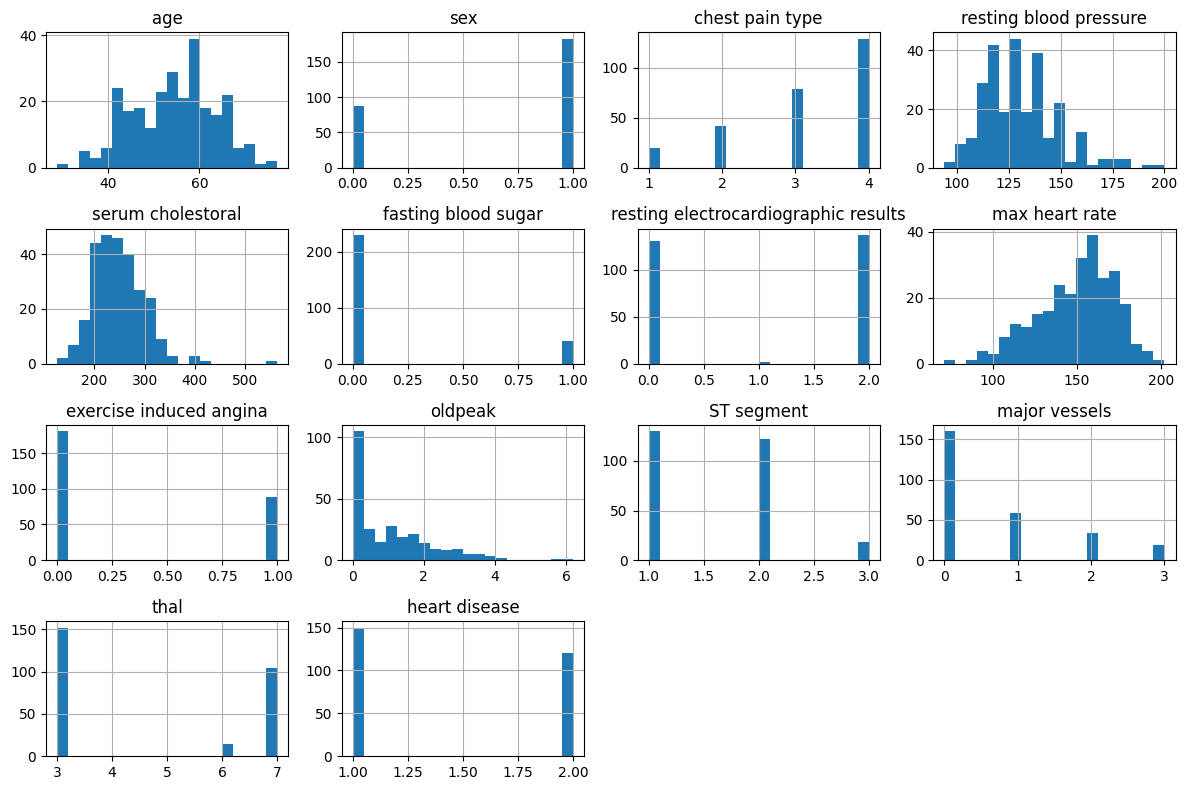

In [8]:
# Select numeric columns (int or float)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms for a few numeric columns
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


## Preprocessing pipeline

In [9]:
# categorical columns (object, category, bool)
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns
# numeric columns (int, float)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)


## Helper - evaluation function

In [10]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # predictions
    y_pred = model.predict(X_test)

    # compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1':  f1_score(y_test, y_pred)
    }
    print(name, metrics)

    # confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    plt.figure(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()
    # ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - ROC Curve')
        plt.legend(loc="lower right")
        plt.show()

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression (no grid) {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


<Figure size 1000x1000 with 0 Axes>

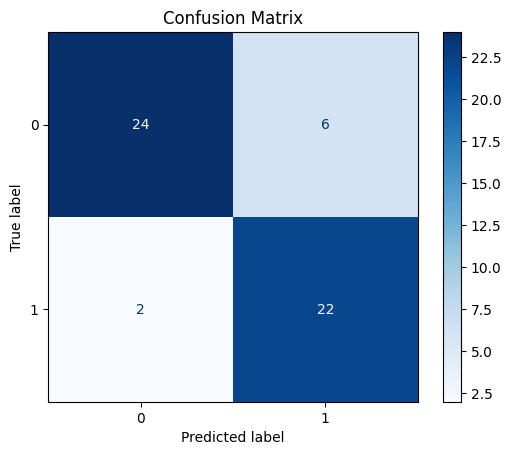

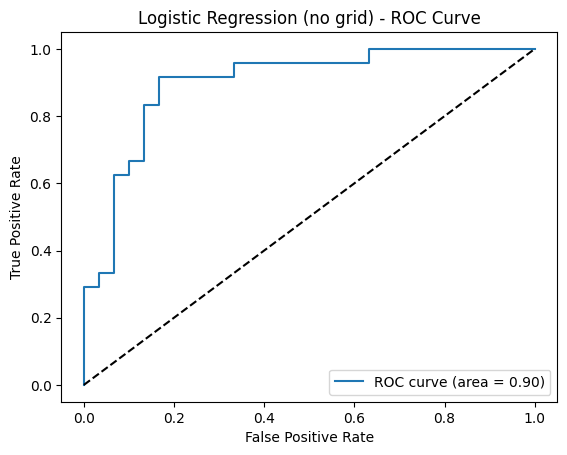

In [11]:
# create a Pipeline with your preprocessor and LogisticRegression
pipe_lr = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# fit on training data
pipe_lr.fit(X_train, y_train)

# evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report("Logistic Regression (no grid)", pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
LR grid {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


<Figure size 1000x1000 with 0 Axes>

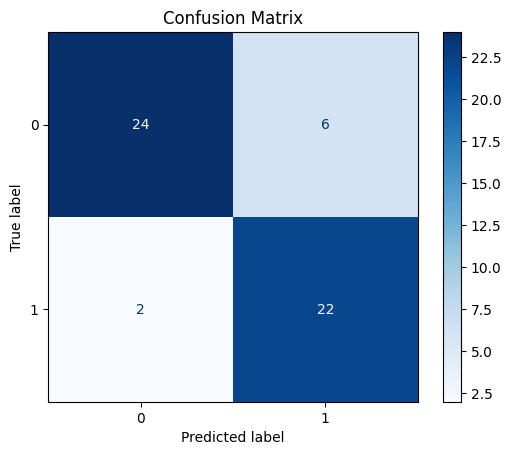

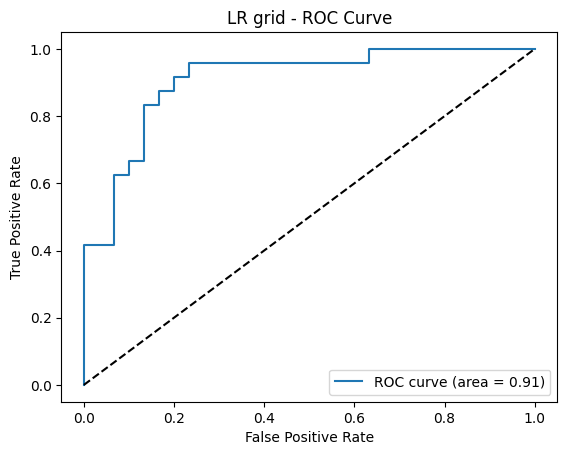

In [12]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(
    [
        ('pre', pre),
        ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
    ]
)

#define param_grid for lr__C and lr__penalty
# use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],   # regularization strength
    'lr__penalty': ['l1', 'l2']         # type of regularization(lasso & ridge)
}

# GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(
    estimator=pipe_lr_cv,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train , y_train )
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


<Figure size 1000x1000 with 0 Axes>

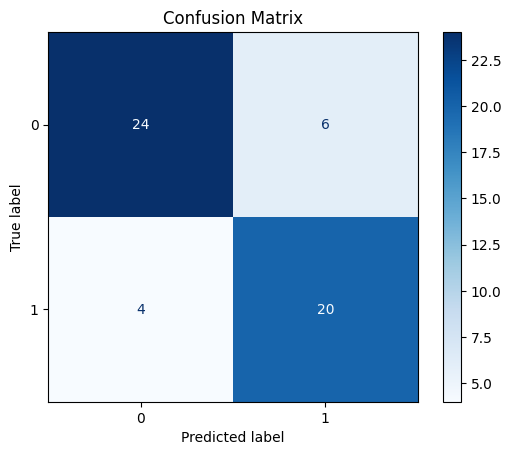

In [13]:
#  choose kernel and hyperparameters for SVC
#try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('pre', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])
pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


<Figure size 1000x1000 with 0 Axes>

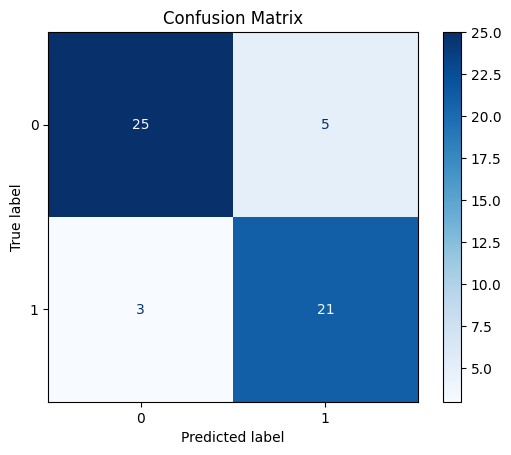

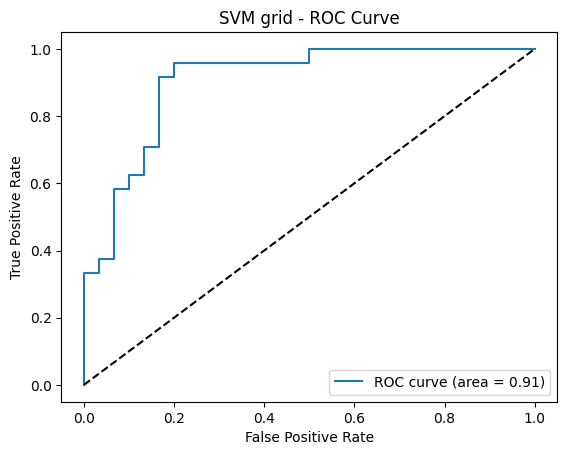

In [14]:
# Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('pre', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

#  param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],   # kernel type
    'svm__C': [0.1, 1, 10, 100],        # regularization strength
    'svm__gamma': ['scale', 'auto']     # kernel coefficient
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(
    estimator=pipe_svm_cv,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Step 1: Fit the grid search
grid_svm.fit(X_train, y_train)

# Step 2: Access best estimator and params
print("Best params:", grid_svm.best_params_)
best_svm = grid_svm.best_estimator_

svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


<Figure size 1000x1000 with 0 Axes>

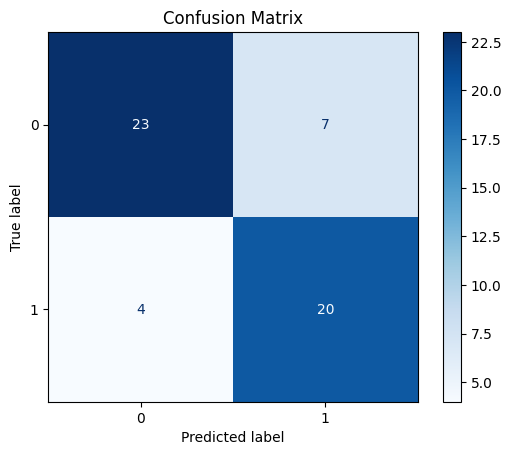

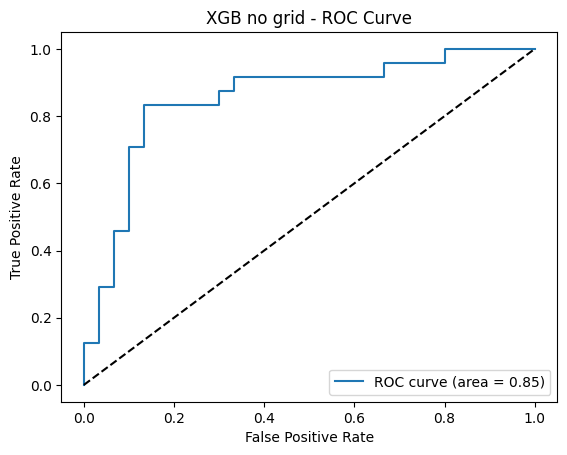

In [17]:
# build an XGBClassifier and wrap it in a Pipeline with pre
# start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE))
])
pipe_xgb.fit(X_train, y_train)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
XGB grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


<Figure size 1000x1000 with 0 Axes>

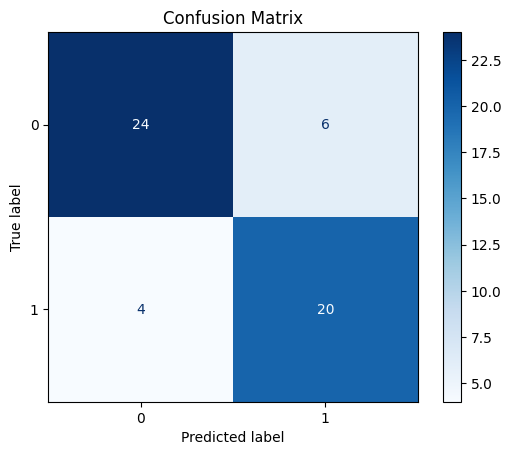

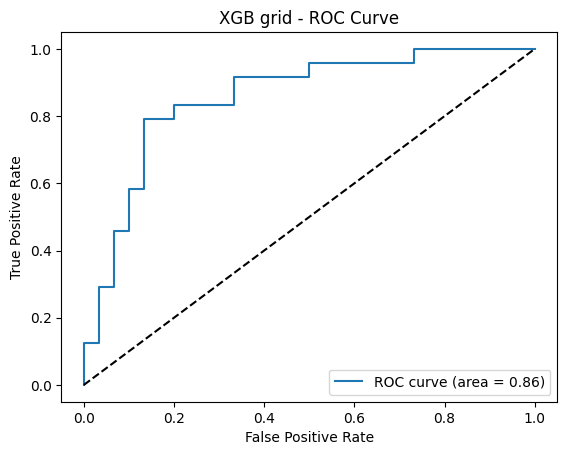

In [19]:
# Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE))
])

# define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],        # number of boosting rounds (trees)
    'xgb__learning_rate': [0.01, 0.1, 0.2],      # step size shrinkage
    'xgb__max_depth': [3, 5, 7],                 # maximum depth of trees
    'xgb__subsample': [0.8, 1.0],                # fraction of samples used per tree
    'xgb__colsample_bytree': [0.8, 1.0]          # fraction of features used per tree
}

#  GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(
    estimator=pipe_xgb_cv,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)


## Compare models

In [23]:
import pandas as pd

summary = {
    name: metrics
    for name, metrics in [
        ("LR no grid", lr_no_gs_metrics),
        ("LR grid", lr_gs_metrics),
        ("SVM no grid", svm_no_metrics),
        ("SVM grid", svm_gs_metrics),
        ("XGB no grid", xgb_no_metrics),
        ("XGB grid", xgb_gs_metrics),
    ]
}

summary_df = pd.DataFrame.from_dict(summary, orient="index")
print(summary_df)



             accuracy  precision    recall        f1
LR no grid   0.851852   0.785714  0.916667  0.846154
LR grid      0.851852   0.785714  0.916667  0.846154
SVM no grid  0.814815   0.769231  0.833333  0.800000
SVM grid     0.851852   0.807692  0.875000  0.840000
XGB no grid  0.796296   0.740741  0.833333  0.784314
XGB grid     0.814815   0.769231  0.833333  0.800000
